In [5]:
import sys
import os
import glob
from scipy import stats

import dabest

import numpy as np
import scipy as sp
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [7]:
#initial file processing

workcomp = "C:\\Users\\User"
laptop = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = homecomp

filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Cell stainings\\"
mip_csv = "ACR eOPN3 MIP Posterior vs Anterior.csv"     
sum_csv = "ACR eOPN3 SUM Posterior vs Anterior.csv"

df_mip=pd.read_csv(specifiedpath + filedir + mip_csv)
df_sum= pd.read_csv(specifiedpath + filedir + sum_csv)


# Set up Inter font
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

In [8]:
df  = df_mip.replace({"ACR1": "GtACR1", "eOPN3": "AsOPN3"}, regex=True)
df1 = df.iloc[0:36,0:5]
df1["Genotype_Position"] = df["Genotype"] + " " + df["Position"]

paired_delta2 = dabest.load(data = df1, idx = (("GtACR1 Posterior", "GtACR1 Anterior"), ("AsOPN3 Posterior", "AsOPN3 Anterior")), paired= 'baseline', id_col="ID",
                            x = "Genotype_Position", y="Value")

In [ ]:
#for delta g
df  = df_mip.replace({"ACR1": "GtACR1", "eOPN3": "AsOPN3"}, regex=True)
df1 = df.iloc[0:36,0:5]
df1["Genotype_Position"] = df["Genotype"] + " " + df["Position"]

paired_delta2 = dabest.load(data = df1, x = ["Position", "Genotype"], y = "Value", delta2 = True, 
                            experiment = "Genotype", x1_level = ["Posterior", "Anterior"], paired = 'baseline', id_col = "ID" )

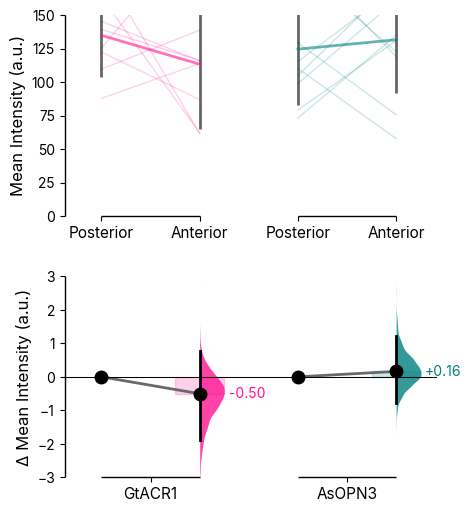

In [16]:


df  = df_mip.replace({"ACR1": "GtACR1", "eOPN3": "AsOPN3"}, regex=True)
df1 = df.iloc[0:36,0:5].copy()
df1["Genotype_Position"] = df["Genotype"] + " " + df["Position"]

paired_data = dabest.load(data = df1, 
                          idx = (("GtACR1 Posterior", "GtACR1 Anterior"), ("AsOPN3 Posterior", "AsOPN3 Anterior")), 
                          paired='baseline', id_col="ID",
                          x = "Genotype_Position", y="Value")

palette = {'GtACR1 Posterior':'deeppink','GtACR1 Anterior':'deeppink', 
           'AsOPN3 Posterior' : 'teal', 'AsOPN3 Anterior' : 'teal'}
genoListNL = ['GtACR1','AsOPN3']

compare = paired_data.hedges_g.plot(fontsize_rawxlabel=9, fontsize_contrastxlabel=9, 
                                    contrast_ylim=(-3, 3), raw_ylim=(0, 150), 
                                    custom_palette=palette, raw_desat=1, contrast_desat=1)
ax_raw = compare.axes[0]

n_gtacr1 = len(df1[df1['Genotype'] == 'GtACR1']['ID'].unique())
n_asopn3 = len(df1[df1['Genotype'] == 'AsOPN3']['ID'].unique())

for line in ax_raw.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2:
        if xdata[0] < 1.5:  
            line.set_color('deeppink')
        else:  # AsOPN3 group 
            line.set_color('teal')

compare.axes[0].set_xticklabels(["Posterior", "Anterior", "Posterior", "Anterior"], fontsize=11)
compare.axes[0].set_ylabel('Mean Intensity (a.u.)')
compare.axes[1].set_ylabel('Δ Mean Intensity (a.u.)')

compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels(genoListNL, fontsize=11)

# Color the contrast effect size violin/points
for i in range(len(genoListNL)):
    compare.axes[1].collections[i].set_color(palette[genoListNL[i] + ' Posterior'])

mpl.rcParams['svg.fonttype'] = 'none'
plt.show()
compare.savefig(specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Cell stainings\\posterioranterior.svg", bbox_inches="tight") 